In [7]:
import cv2 as cv
import numpy as np
from bordas import det_roberts, det_prewitt, det_sobel, det_scharr, det_laplaciano, det_LoG, det_DoG, det_canny
from funcoespi import exibir_resultados

In [8]:
# Carregar imagem
estrada_bgr = cv.imread('data/estrada.png')

# Implementação de Roberts

In [9]:
# Implementação Opencv
estrada_manual_roberts = det_roberts(estrada_bgr)

# Implementação OpenCV (simulando Roberts com filter2D)
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float64)
kernel_gx = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_gy = np.array([[0, 1], [-1, 0]], dtype=np.float64)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)
magnitude = np.sqrt(gx ** 2 + gy ** 2)
estrada_opencv_roberts = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

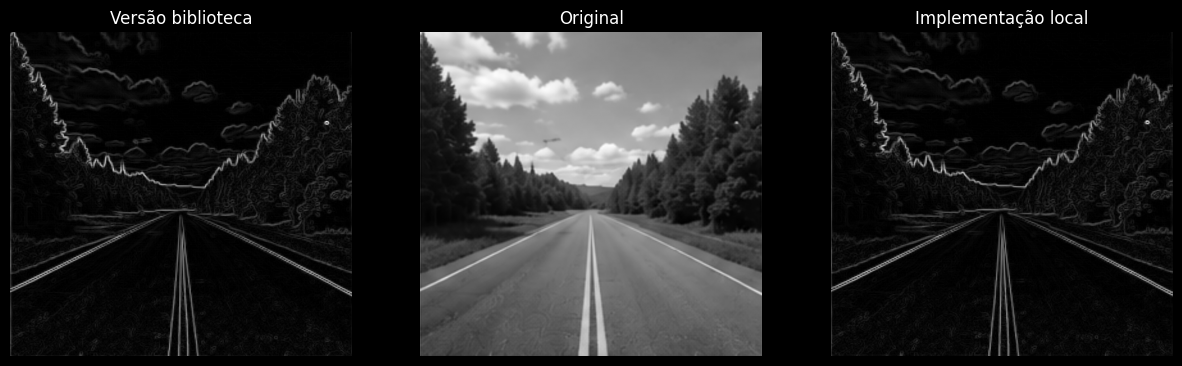

In [10]:
# Exibição em Grayscale
exibir_resultados(estrada_opencv_roberts, estrada_bgr, estrada_manual_roberts)


# Implementação de Prewitt

In [11]:
# Implementação Manual
estrada_manual_prewitt = det_prewitt(estrada_bgr)

# Implementação OpenCV usando filter2D
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float32)

kernel_gx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

kernel_gy = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)

magnitude = np.sqrt(gx ** 2 + gy ** 2)

estrada_opencv_prewitt = cv.normalize(
    magnitude, None, 0, 255, cv.NORM_MINMAX
).astype(np.uint8)

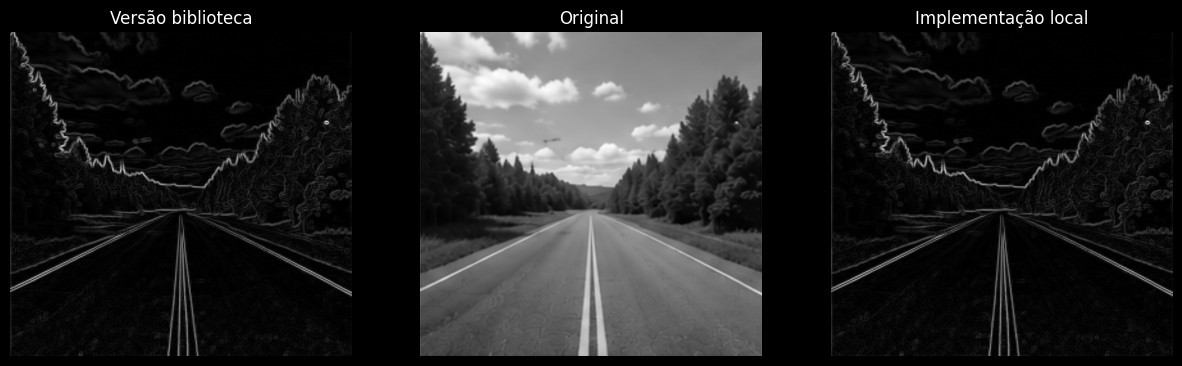

In [12]:
exibir_resultados(estrada_opencv_prewitt, estrada_bgr, estrada_manual_prewitt)

# Implementação de Sobel

In [13]:
# Implementação Manual
estrada_manual_sobel = det_sobel(estrada_bgr)

# Implementação OpenCV usando Sobel

gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY)
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobelx ** 2 + sobely ** 2)
estrada_opencv_sobel = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

TypeError: Image data of dtype object cannot be converted to float

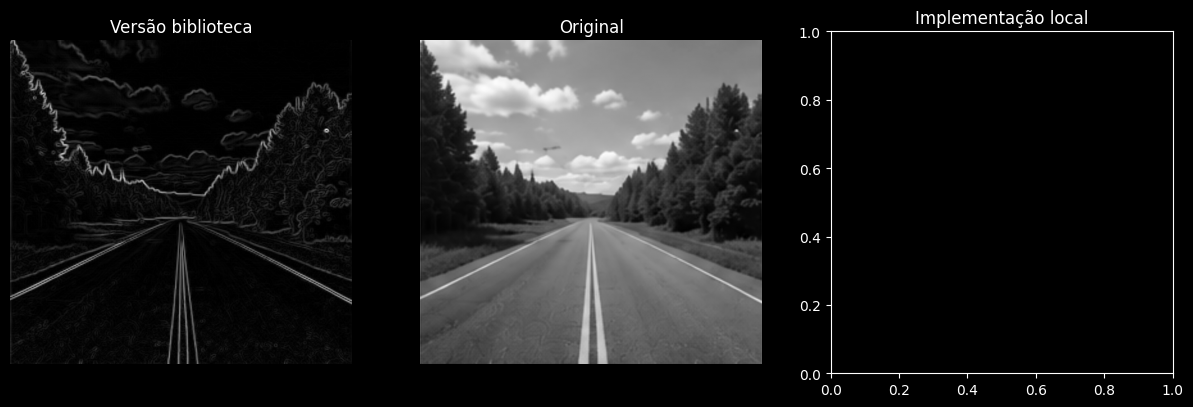

In [15]:
exibir_resultados(estrada_opencv_sobel, estrada_bgr, estrada_manual_sobel)